In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore
from scipy.ndimage import gaussian_filter1d

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)

def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [4]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [5]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [ ]:
### Function to get aligned dataframe for closed loop sessions.
def live_aligned_df(mouse_id,date,sess = "1",pre = 10,post = 10):

    path_start = fr"{base_dir}/{mouse_id}/{date}/"
    df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_areas.csv", names=["Area","Time"])
    dilation_df = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_dilations.csv", names=["Times"])
    lasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_laser.csv", names=["Times"])["Times"].tolist()
    nonlasers = pd.read_csv(fr"{path_start}{mouse_id}_{date}_{sess}_nonlasers.csv", names=["Times"])["Times"].tolist()

    dil_times = dilation_df["Times"].tolist()
    Area = df["Area"].tolist()
    Area =[x if x != 0 else np.nan for x in Area]
    Time = [i - df["Time"].tolist()[0] for i in df["Time"].tolist()]
    Dil_times = [i - df["Time"].tolist()[0] for i in dil_times]
    Lasers = [i - df["Time"].tolist()[0] for i in lasers]
    Nonlasers = [i - df["Time"].tolist()[0] for i in nonlasers]
    nan_removed_area = np.delete(Area, np.argwhere(np.isnan(Area)))
    nan_removed_times = np.delete(Time, np.argwhere(np.isnan(Area)))
    Time = np.arange(0,Time[-1],0.05)
    area = np.interp(Time, nan_removed_times, nan_removed_area)
    Area = zscore(area)
    Lasers = np.array(Lasers)
    Nonlasers = np.array(Nonlasers)
    Time = np.array(Time)
    Area = np.array(Area)
    laser_matrix,dil_times = trial_align(Lasers,Time,Area,fps = 20,pre = pre, post = post)
    df_list = []
    for j,trial in enumerate(laser_matrix):
        ##check if slope during trial is positive
        p = gaussian_filter1d(trial,20)
        p_deriv = np.gradient(p,dil_times)
        slope = np.mean(p_deriv[160:200])
        if slope >0:
            for i,time in enumerate(dil_times):
                new_dict = {"Time from Stim (s)" : np.round(time,2), "trial" : j, "Pupil Area" : trial[i],"Type":"Laser Trial","ID":mouse_id,"Date":date}
                df_list.append(new_dict)

    nonlaser_matrix,dil_times = trial_align(Nonlasers,Time,Area,fps = 20,pre = pre, post = post)
    for j,trial in enumerate(nonlaser_matrix):
        ##check if slope during trial is positive
        p = gaussian_filter1d(trial,20)
        p_deriv = np.gradient(p,dil_times)
        slope = np.mean(p_deriv[160:200])
        if slope >0:
            for i,time in enumerate(dil_times):
                new_dict = {"Time from Stim (s)" : np.round(time,2), "trial" : j, "Pupil Area" : trial[i],"Type":"Non-Laser Trial","ID":mouse_id,"Date":date}
                df_list.append(new_dict)
    aligned_df = pd.DataFrame.from_dict(df_list)
    return aligned_df


In [ ]:
### Get data for Fig3C

id_date = { 
"004072" : ["20230727","20230726"],
"004075" : ["20230727","20230726"],
"004109" : ["20230907","20230908"],
"004112" : ["20230908"],
"004110" : ["20230911"],
"004111" : ["20230911"]
}

df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = live_aligned_df(id,date,"1",post = 15)
        df_list.append(df)
df = pd.concat(df_list)
ACC_df = df.reset_index()

004072 20230727
004072 20230726
004075 20230727
004075 20230726
004109 20230907
004109 20230908
004112 20230908
004110 20230911
004111 20230911


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/1787545457.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = ACC_df.groupby(["ID","Type","Time from Stim (s)"]).mean().reset_index(), x = "Time from Stim (s)", y = "Pupil Area",errorbar = "se",palette = ["dodgerblue","black"],linewidth = 1,hue = "Type",legend= None)


Text(0, 0.5, 'Pupil size (z-scr)')

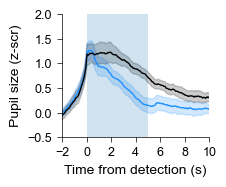

In [ ]:
### Plot Fig3C
plt.figure(figsize = (1.9,1.6))

ax = sns.lineplot(data = ACC_df.groupby(["ID","Type","Time from Stim (s)"]).mean().reset_index(), x = "Time from Stim (s)", y = "Pupil Area",errorbar = "se",palette = ["dodgerblue","black"],linewidth = 1,hue = "Type",legend= None)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,10],[-0.5,2],2,0.5)
ax.set_xlabel("Time from detection (s)")
ax.set_ylabel("Pupil size (z-scr)")


In [36]:
### Get data for Fig3D, 3E
bar_df_list = []
for ID in ACC_df.ID.unique():
    mouse_df = ACC_df.query(f"ID =='{ID}'")
    for type in mouse_df.Type.unique():
        type_df = mouse_df.query(f"Type =='{type}'")
        rslt_df = type_df.loc[type_df['Time from Stim (s)'] > 0]
        rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 5]
        area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
        time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
        peak = max(area)
        peak_ix = np.argmax(area)
        p_50 = peak*0.5
        p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
        detection = area[0]
        time_to_50 = (p_50_ix-peak_ix)/20
        new_dict = {"ID" : ID,"type": type,"T50":time_to_50,"Peak":peak,"AUC":np.trapz(area,time),"Detection":detection}
        bar_df_list.append(new_dict)

ACC_metrics_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/933395049.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/933395049.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/933395049.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecate

[Text(0, 0, 'Non\nlaser'), Text(1, 0, 'Laser')]

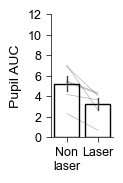

In [37]:
### Plot Fig3D

plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = ACC_metrics_df, x = "type", y = "AUC",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = ACC_metrics_df, x = "type", y = "AUC",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,14,2))
g.set(ylim=(0, 12))
g.set_ylabel("Pupil AUC")
g.xaxis.label.set_visible(False)
labels = ["Non\nlaser","Laser"]
g.set_xticklabels(labels)

[Text(0, 0, 'Non\nlaser'), Text(1, 0, 'Laser')]

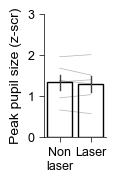

In [38]:
### Plot Fig3E
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = ACC_metrics_df, x = "type", y = "Peak",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = ACC_metrics_df, x = "type", y = "Peak",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,4,1))
g.set(ylim=(0, 3))
g.set_ylabel("Peak pupil size (z-scr)")
g.xaxis.label.set_visible(False)
labels = ["Non\nlaser","Laser"]
g.set_xticklabels(labels)

In [34]:
### Get data for Fig3F
bar_df_list = []
for ID in ACC_df.ID.unique():
    mouse_df = ACC_df.query(f"ID =='{ID}'")
    for type in mouse_df.Type.unique():
        type_df = mouse_df.query(f"Type =='{type}'")
        rslt_df = type_df.loc[type_df['Time from Stim (s)'] > 0]
        rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 10]
        area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
        time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
        peak = max(area)
        peak_ix = np.argmax(area)
        p_50 = peak*0.5
        p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
        detection = area[0]
        time_to_50 = (p_50_ix-peak_ix)/20
        new_dict = {"ID" : ID,"type": type,"T50":time_to_50}
        bar_df_list.append(new_dict)

ACC_t50_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/1130012501.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/1130012501.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/1130012501.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprec

[Text(0, 0, 'Non\nlaser'), Text(1, 0, 'Laser')]

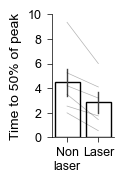

In [39]:
### Plot Fig3F
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = ACC_t50_df, x = "type", y = "T50",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = ACC_t50_df, x = "type", y = "T50",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,12,2))
g.set(ylim=(0, 10))
g.set_ylabel("Time to 50% of peak")
g.xaxis.label.set_visible(False)
labels = ["Non\nlaser","Laser"]
g.set_xticklabels(labels)

In [43]:
### Get data for Fig3G

id_date = { 
"004259" : ["20240514"],
"004260" : ["20240514","20240517"],
"004261" : ["20240514"],
"004262" : ["20240514","20240522"],
"004263" : ["20240522"],
"004264" : ["20240514"],
 }

df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = live_aligned_df(id,date,"1",post = 15)
        df_list.append(df)
df = pd.concat(df_list)
mcherry_df = df.reset_index()

004259 20240514
004260 20240514
004260 20240517
004261 20240514
004262 20240514
004262 20240522
004263 20240522
004264 20240514


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/4132506611.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = mcherry_df.groupby(["ID","Type","Time from Stim (s)"]).mean().reset_index(), x = "Time from Stim (s)", y = "Pupil Area",errorbar = "se",palette = ["dodgerblue","black"],linewidth = 1,hue = "Type",legend= None)


Text(0, 0.5, 'Pupil size (z-scr)')

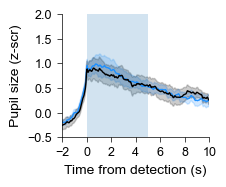

In [ ]:
### Plot Fig3G

plt.figure(figsize = (1.9,1.6))

ax = sns.lineplot(data = mcherry_df.groupby(["ID","Type","Time from Stim (s)"]).mean().reset_index(), x = "Time from Stim (s)", y = "Pupil Area",errorbar = "se",palette = ["dodgerblue","black"],linewidth = 1,hue = "Type",legend= None)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,10],[-0.5,2],2,0.5)
ax.set_xlabel("Time from detection (s)")
ax.set_ylabel("Pupil size (z-scr)")

In [ ]:
### Get data for Fig3H, 3I
bar_df_list = []
for ID in mcherry_df.ID.unique():
    mouse_df = mcherry_df.query(f"ID =='{ID}'")
    for type in mouse_df.Type.unique():
        type_df = mouse_df.query(f"Type =='{type}'")
        rslt_df = type_df.loc[type_df['Time from Stim (s)'] > 0]
        rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 5]
        area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
        time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
        peak = max(area)
        peak_ix = np.argmax(area)
        p_50 = peak*0.5
        p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
        detection = area[0]
        time_to_50 = (p_50_ix-peak_ix)/20
        new_dict = {"ID" : ID,"type": type,"T50":time_to_50,"Peak":peak,"AUC":np.trapz(area,time),"Detection":detection}
        bar_df_list.append(new_dict)


mcherry_metrics_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/995942571.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/995942571.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/995942571.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecate

[Text(0, 0, 'Non\nLaser'), Text(1, 0, 'Laser')]

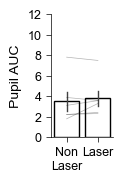

In [ ]:
### Plot Fig3H
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = mcherry_metrics_df, x = "type", y = "AUC",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = mcherry_metrics_df, x = "type", y = "AUC",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,14,2))
g.set(ylim=(0, 12))
g.set_ylabel("Pupil AUC")
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)

[Text(0, 0, 'Non\nLaser'), Text(1, 0, 'Laser')]

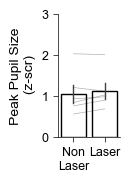

In [ ]:
### Plot Fig3I
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = mcherry_metrics_df, x = "type", y = "Peak",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = mcherry_metrics_df, x = "type", y = "Peak",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,4,1))
g.set(ylim=(0, 3))
g.set_ylabel("Peak Pupil Size\n (z-scr)")
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)

In [ ]:
### Get data for Fig3J
bar_df_list = []
for ID in mcherry_df.ID.unique():
    mouse_df = mcherry_df.query(f"ID =='{ID}'")
    for type in mouse_df.Type.unique():
        type_df = mouse_df.query(f"Type =='{type}'")
        rslt_df = type_df.loc[type_df['Time from Stim (s)'] > 0]
        rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 10]
        area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
        time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
        peak = max(area)
        peak_ix = np.argmax(area)
        p_50 = peak*0.5
        p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
        time_to_50 = (p_50_ix-peak_ix)/20
        new_dict = {"ID" : ID,"type": type,"T50":time_to_50}
        bar_df_list.append(new_dict)


mcherry_t50_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/453605186.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/453605186.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/453605186.py:9: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecate

[Text(0, 0, 'Non\nLaser'), Text(1, 0, 'Laser')]

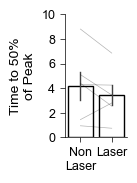

In [ ]:
### Plot Fig3J
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = mcherry_t50_df, x = "type", y = "T50",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = mcherry_t50_df, x = "type", y = "T50",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,12,2))
g.set(ylim=(0, 10))
g.set_ylabel("Time to 50%\nof Peak")
g.xaxis.label.set_visible(False)
labels = ["Non\nLaser","Laser"]
g.set_xticklabels(labels)

In [52]:
### Get data for Fig3K

id_date = { 
"004253" : ["20240520"],
"004254" : ["20240521"],
"004255" : ["20240521"],
"004256" : ["20240521"],
"004257" : ["20240521"],
"004258" : ["20240521"],
 }

df_list = []
for id,dates in id_date.items():
    for date in dates:
        print(id,date)
        df = live_aligned_df(id,date,"1",post = 15)
        df_list.append(df)
df = pd.concat(df_list)
v1_df = df.reset_index()

004253 20240520
004254 20240521
004255 20240521
004256 20240521
004257 20240521
004258 20240521


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/1001217783.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = v1_df.groupby(["ID","Type","Time from Stim (s)"]).mean().reset_index(), x = "Time from Stim (s)", y = "Pupil Area",errorbar = "se",palette = ["dodgerblue","black"],linewidth = 1,hue = "Type",legend= None)


Text(0, 0.5, 'Pupil size (z-scr)')

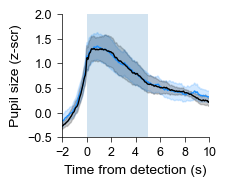

In [53]:
### Plot Fig3K

plt.figure(figsize = (1.9,1.6))

ax = sns.lineplot(data = v1_df.groupby(["ID","Type","Time from Stim (s)"]).mean().reset_index(), x = "Time from Stim (s)", y = "Pupil Area",errorbar = "se",palette = ["dodgerblue","black"],linewidth = 1,hue = "Type",legend= None)
ax.axvspan(0,5,alpha = 0.2)
format_ax(ax,[-2,10],[-0.5,2],2,0.5)
ax.set_xlabel("Time from detection (s)")
ax.set_ylabel("Pupil size (z-scr)")

In [ ]:
### Get data for Fig3L, 3M

bar_df_list = []
for ID in v1_df.ID.unique():
    mouse_df = v1_df.query(f"ID =='{ID}'")
    for type in mouse_df.Type.unique():
        type_df = mouse_df.query(f"Type =='{type}'")
        rslt_df = type_df.loc[type_df['Time from Stim (s)'] > 0]
        rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 5]
        area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
        time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
        peak = max(area)
        peak_ix = np.argmax(area)
        p_50 = peak*0.5
        p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
        time_to_50 = (p_50_ix-peak_ix)/20
        new_dict = {"ID" : ID,"type": type,"T50":time_to_50,"Peak":peak,"AUC":np.trapz(area,time),"Detection":detection}
        bar_df_list.append(new_dict)


v1_metrics_df = pd.DataFrame.from_dict(bar_df_list)

Laser Trial
Non-Laser Trial
Laser Trial
Non-Laser Trial
Laser Trial
Non-Laser Trial
Laser Trial
Non-Laser Trial
Laser Trial
Non-Laser Trial
Laser Trial
Non-Laser Trial


/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/3344459448.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/3344459448.py:11: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/3344459448.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depr

[Text(0, 0, 'Non\nlaser'), Text(1, 0, 'Laser')]

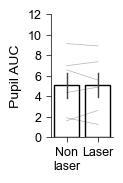

In [55]:
### Plot Fig 3L
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = v1_metrics_df, x = "type", y = "AUC",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = v1_metrics_df, x = "type", y = "AUC",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,14,2))
g.set(ylim=(0, 12))
g.set_ylabel("Pupil AUC")
g.xaxis.label.set_visible(False)
labels = ["Non\nlaser","Laser"]
g.set_xticklabels(labels)

[Text(0, 0, 'Non\nlaser'), Text(1, 0, 'Laser')]

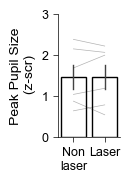

In [56]:
### Plot Fig3M
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = v1_metrics_df, x = "type", y = "Peak",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = v1_metrics_df, x = "type", y = "Peak",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,4,1))
g.set(ylim=(0, 3))
g.set_ylabel("Peak Pupil Size\n (z-scr)")
g.xaxis.label.set_visible(False)
labels = ["Non\nlaser","Laser"]
g.set_xticklabels(labels)

In [58]:
### Get data for Fig3N

bar_df_list = []
for ID in v1_df.ID.unique():
    mouse_df = v1_df.query(f"ID =='{ID}'")
    for type in mouse_df.Type.unique():
        type_df = mouse_df.query(f"Type =='{type}'")
        rslt_df = type_df.loc[type_df['Time from Stim (s)'] > 0]
        rslt_df = rslt_df.loc[rslt_df['Time from Stim (s)'] < 10]
        area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
        time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
        peak = max(area)
        peak_ix = np.argmax(area)
        p_50 = peak*0.5
        p_50_ix = np.absolute(area[peak_ix:]-p_50).argmin() + peak_ix
        time_to_50 = (p_50_ix-peak_ix)/20
        new_dict = {"ID" : ID,"type": type,"T50":time_to_50}
        bar_df_list.append(new_dict)

v1_t50_df = pd.DataFrame.from_dict(bar_df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/339426069.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  area = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Pupil Area"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/339426069.py:11: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  time = np.array(rslt_df.groupby(["Time from Stim (s)"]).mean().reset_index()["Time from Stim (s)"])
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_17928/339426069.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is depreca

[Text(0, 0, 'Non\nlaser'), Text(1, 0, 'Laser')]

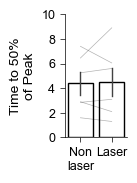

In [ ]:
### Plot Fig3N
plt.figure(figsize = (0.8,1.6))
g = sns.barplot(data = v1_t50_df, x = "type", y = "T50",errorbar = "se",fill = None,errwidth= 1,order = ["Non-Laser Trial", "Laser Trial"])
sns.lineplot(data = v1_t50_df, x = "type", y = "T50",units = "ID",estimator = None,color = "black",alpha = 0.3,linewidth = 0.5)
for line in g.get_lines()[2:]:
    y1,y2 = line.get_ydata()
    line.set_ydata([y2,y1])

g.set_yticks(np.arange(0,12,2))
g.set(ylim=(0, 10))
g.set_ylabel("Time to 50%\nof Peak")
g.xaxis.label.set_visible(False)
labels = ["Non\nlaser","Laser"]
g.set_xticklabels(labels)